# Software Project: Detectia traficului de tip Network Fuzzing folosind algoritmi de Machine Learning

Acest proiect prezinta o analiza comparativa a rezultatelor modelelor Mahine Learning: LR, RF, DT, XGBoost, antrenate pe setul de date UNSW-NB15, pentru detectarea traficului de retea de tip **FUZZING**


## 1. Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Procesare date - comasare si stratified split (80/20)

In [42]:
def prepare_final_data(train_path, test_path):
    df1 = pd.read_csv(train_path)
    df2 = pd.read_csv(test_path)
    full_df = pd.concat([df1, df2], axis=0)
    
    # filtrare dupa categorie
    df = full_df[(full_df['attack_cat'] == 'Fuzzers') | (full_df['attack_cat'] == 'Normal')].copy()
    df['label'] = (df['attack_cat'] == 'Fuzzers').astype(int)
    
    # stratified split 80/20
    train_set, test_set = train_test_split(
        df, test_size=0.2, stratify=df['label'], random_state=42
    )
    return train_set, test_set

train, test = prepare_final_data("../data/UNSW_NB15_training-set.csv", "../data/UNSW_NB15_testing-set.csv")
print(f"Train set distribution: {train['label'].value_counts(normalize=True)}")
print(f"Test set distribution: {test['label'].value_counts(normalize=True)}")

Train set distribution: label
0    0.7932
1    0.2068
Name: proportion, dtype: float64
Test set distribution: label
0    0.79322
1    0.20678
Name: proportion, dtype: float64


### 2.1 Exploratory Data Analysis (EDA)

Evidentiaza dezechilibrul de clase si distributia feature-urilor importante -> necesita preprocesare.

In [43]:
def plot_class_distribution(y, title="Class Distribution"):
    plt.figure(figsize=(8, 5))
    labels = ['Normal' if val == 0 else 'Fuzzers' for val in y]
    sns.countplot(x=labels, palette='viridis')
    plt.title(title)
    plt.ylabel('Count')
    plt.show()

/tmp/ipykernel_166430/1959672483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='viridis')


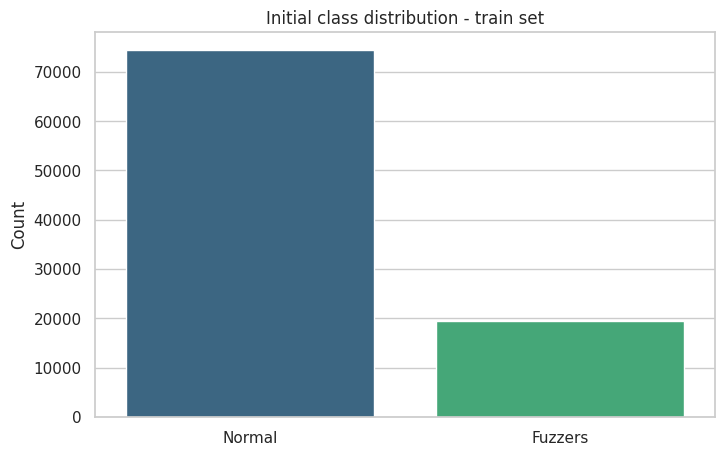

/tmp/ipykernel_166430/4208740066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=train, palette='Set2')
/tmp/ipykernel_166430/4208740066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=train, palette='Set2')
/tmp/ipykernel_166430/4208740066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=train, palette='Set2')
/tmp/ipykernel_166430/4208740066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

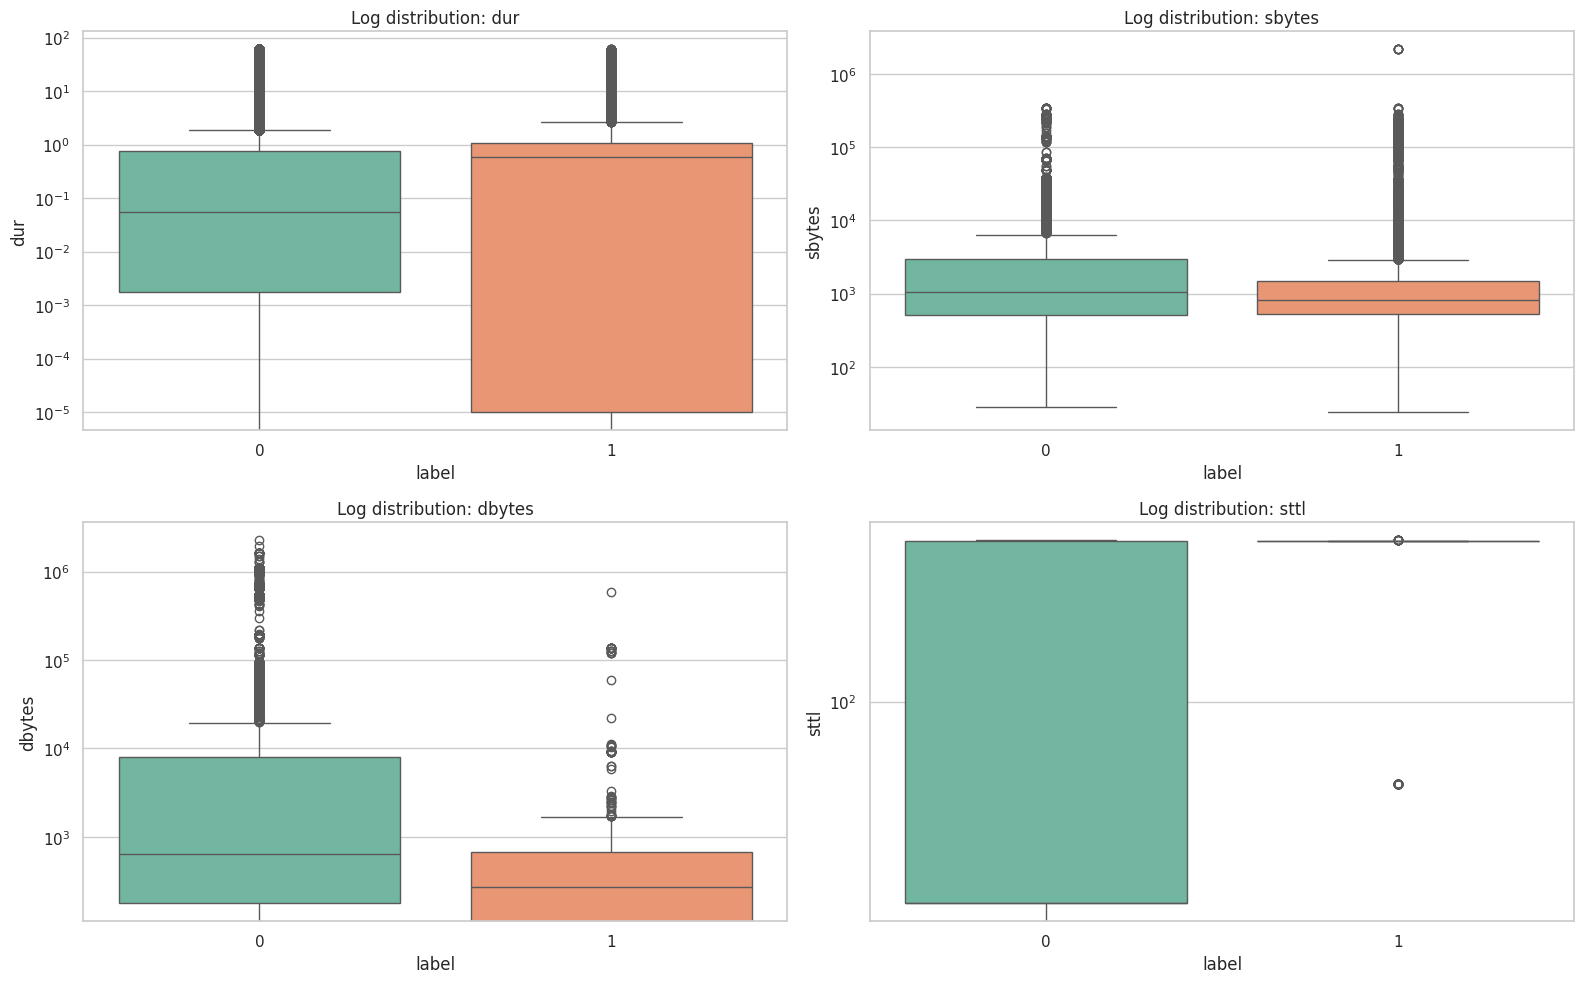

In [44]:
# distributie clase
plot_class_distribution(train['label'], "Initial class distribution - train set")

# boxplot - imp features
key_features = ['dur', 'sbytes', 'dbytes', 'sttl']
plt.figure(figsize=(16, 10))

for i, col in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='label', y=col, data=train, palette='Set2')
    plt.yscale('log')
    plt.title(f'Log distribution: {col}')

plt.tight_layout()
plt.show()

## 3. Preprocesare și SMOTE

SMOTE completat.


/tmp/ipykernel_166430/1959672483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='viridis')


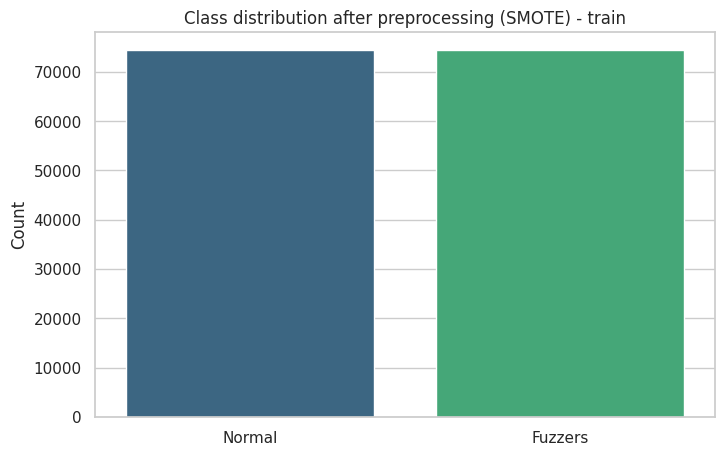

In [45]:
def final_preprocess(train_df, test_df):
    train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    le_dict = {}
    for col in ['proto', 'service', 'state']:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col] = test_df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
        le_dict[col] = le
        
    X_train = train_df.drop(columns=['id', 'attack_cat', 'label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['id', 'attack_cat', 'label'])
    y_test = test_df['label']
    
    return X_train, X_test, y_train, y_test, le_dict

X_train, X_test, y_train, y_test, le_dict = final_preprocess(train, test)
feature_names = X_train.columns

# Echilibram clasele cu alg SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("SMOTE completat.")
plot_class_distribution(y_train_res, "Class distribution after preprocessing (SMOTE) - train")

## 4. Evaluare rezultate modele antrenate

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
}

final_metrics = {}
trained_models = {}

for name, model in models.items():
    X_train_eval = X_train_res
    X_test_eval = X_test
    
    # Scalare date pentru LR
    if name == 'Logistic Regression':
        scaler = StandardScaler()
        X_train_eval = scaler.fit_transform(X_train_res)
        X_test_eval = scaler.transform(X_test)
        trained_scaler = scaler # saving it for later
        
    model.fit(X_train_eval, y_train_res)
    y_pred = model.predict(X_test_eval)
    y_proba = model.predict_proba(X_test_eval)[:, 1]
    
    final_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    trained_models[name] = model

# metrici evaluare
df_results = pd.DataFrame(final_metrics).T
df_results

,Accuracy,Recall,Precision,F1-Score,ROC-AUC
Logistic Regression,0.800682,0.970716,0.509471,0.668228,0.927678
Decision Tree,0.854115,0.890493,0.599057,0.716264,0.938001
Random Forest,0.900341,0.827181,0.727949,0.774399,0.959555
XGBoost,0.889723,0.838317,0.692858,0.758679,0.957486


## 5. Salvare modele antrenate - pentru UI

In [ ]:
import joblib

# save models
for name, model in trained_models.items():
    filename = f"../models/{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)
    print(f"model {name} saved in {filename}")

# save scaler for LR
if 'trained_scaler' in locals():
    joblib.dump(trained_scaler, "../models/scaler.joblib")
    print("scaler saved")

# save dic for LE
if 'le_dict' in locals():
    joblib.dump(le_dict, "../models/encoders.joblib")
    print("encoders saved")

Modelul Logistic Regression a fost salvat în ../models/logistic_regression.joblib
Modelul Decision Tree a fost salvat în ../models/decision_tree.joblib
Modelul Random Forest a fost salvat în ../models/random_forest.joblib
Modelul XGBoost a fost salvat în ../models/xgboost.joblib
Scaler-ul a fost salvat în ../models/scaler.joblib
Encoders au fost salvați în ../models/encoders.joblib
